# 第7回 勉強会 (2) — BERT で感情分析：tokenizer・訓練・エラー分析

ノート1で見た**不均衡な感情分析データ**（Amazon-Reviews-2023）に対して、
教科書 chapter05 のファインチューニングの流れを**圧縮版**でたどります。

1. **tokenizer**：テキスト → 入力ID
2. **前処理 + DataCollator**：ミニバッチ化（動的パディング）
3. **モデル**：事前学習モデル + 分類ヘッド
4. **訓練**：`Trainer`（対処なし／クラス重み付き）
5. **評価**：不均衡では accuracy だけ見てはいけない（macro-F1 / balanced acc / 少数クラス recall / 混同行列）
6. **エラー分析**：自信満々で外した事例

英語データなので、CPUでも軽い英語モデル **`distilbert-base-uncased`** を使います。
（教科書の日本語BERTとは別物ですが、学習の「型」と不均衡の扱いを学ぶ目的には十分）

In [1]:
import japanize_matplotlib  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import Dataset
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
from transformers.trainer_utils import set_seed

from util import load_amazon_binary

%matplotlib inline
plt.rcParams["font.size"] = 12
set_seed(42)

MODEL_NAME = "distilbert-base-uncased"   # 英語・軽量（CPU向け）
LABELS = ["positive", "negative"]         # positive=0 / negative=1（少数派=negative）
MINORITY = 1

/Users/yasuthompson/Documents/llm-book/dai-7-kai/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. データ準備（CPU向けに小さめのサブセット）

`load_amazon_binary()` は星評価を二値化（★4-5→positive / ★1-2→negative / ★3除外）し、
シャッフル済みの配列を返します（詳細は `util.py`）。自然な不均衡比はそのまま保持されます。

In [2]:
texts, labels, _ = load_amazon_binary(max_lines=60000)

EVAL_SIZE, TRAIN_SIZE = 400, 800
valid_ds = Dataset.from_dict(
    {"text": texts[:EVAL_SIZE], "label": labels[:EVAL_SIZE]}
)
train_ds = Dataset.from_dict(
    {"text": texts[EVAL_SIZE:EVAL_SIZE + TRAIN_SIZE],
     "label": labels[EVAL_SIZE:EVAL_SIZE + TRAIN_SIZE]}
)

train_counts = np.bincount(train_ds["label"], minlength=2)
valid_counts = np.bincount(valid_ds["label"], minlength=2)
print(f"train: positive={train_counts[0]} / negative={train_counts[1]} "
      f"(positive率 {train_counts[0] / train_counts.sum():.1%})")
print(f"valid: positive={valid_counts[0]} / negative={valid_counts[1]}")

train: positive=624 / negative=176 (positive率 78.0%)
valid: positive=328 / negative=72


## 1. tokenizer — テキストを「サブワードのID列」に変換

BERT 系は **WordPiece（サブワード）** でトークナイズします（教科書 chapter05 5.2.3 と同じ流れ）。
単語をそのまま使うのではなく、必要に応じて `##` 付きの**部分語**に分割するので、
語彙に無い単語（未知語）も表現できます。

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("トークナイザのクラス:", type(tokenizer).__name__)

example = "This product smells amazing and works great!"
print("入力文   :", example)
print("サブワード:", tokenizer.tokenize(example))

/Users/yasuthompson/Documents/llm-book/dai-7-kai/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


トークナイザのクラス: DistilBertTokenizerFast
入力文   : This product smells amazing and works great!
サブワード: ['this', 'product', 'smells', 'amazing', 'and', 'works', 'great', '!']


珍しい・長い語ほど `##` 付きの部分語に割れます（WordPiece の働き）。

In [4]:
demo = "Absolutely unbelievable moisturizer!!!"
print(demo)
print(tokenizer.tokenize(demo))

Absolutely unbelievable moisturizer!!!
['absolutely', 'unbelievable', 'moist', '##uri', '##zer', '!', '!', '!']


`tokenizer(...)` を呼ぶと、モデルに渡す **`BatchEncoding`** が返ります。

In [5]:
encoded = tokenizer(example)
print("型:", type(encoded).__name__)
encoded

型: BatchEncoding


{'input_ids': [101, 2023, 4031, 14747, 6429, 1998, 2573, 2307, 999, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

- `input_ids`：サブワードを語彙IDに変換したもの
- `attention_mask`：実トークン=1 / パディング=0（→ セクション2で登場）
- ※ DistilBERT は文ペア用の `token_type_ids` を使いません
  （教科書の BERT では2文入力のとき登場します）

ID列を文字列に戻すと、先頭 `[CLS]`・末尾 `[SEP]` という **特殊トークン**が
付いているのが分かります。分類では `[CLS]` の表現からラベルを予測します。

In [6]:
print(tokenizer.convert_ids_to_tokens(encoded["input_ids"]))
print("特殊トークン :", tokenizer.cls_token, tokenizer.sep_token,
      tokenizer.pad_token)
print("PAD のID    :", tokenizer.pad_token_id)

['[CLS]', 'this', 'product', 'smells', 'amazing', 'and', 'works', 'great', '!', '[SEP]']
特殊トークン : [CLS] [SEP] [PAD]
PAD のID    : 0


## 2. 前処理（map）と DataCollator による**動的パディング**

全事例をトークナイズします。文ごとに長さが違うため、ミニバッチにまとめる際は
**短い文を `[PAD]` で埋めて長さを揃え**ます。`DataCollatorWithPadding` は
「**そのバッチ内の最長**」に合わせてパディングします（固定長より無駄が少ない＝**動的パディング**）。

In [7]:
def preprocess(example):
    enc = tokenizer(example["text"], max_length=256, truncation=True)
    enc["labels"] = example["label"]
    return enc


tok_train = train_ds.map(preprocess, remove_columns=train_ds.column_names)
tok_valid = valid_ds.map(preprocess, remove_columns=valid_ds.column_names)

# まず、4件の「素の長さ」がバラバラなことを確認
for i in range(4):
    print(f"事例{i}: {len(tok_train[i]['input_ids']):>3d} トークン")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
Map:   0%|          | 0/800 [00:00<?, ? examples/s]

TOKENIZERS_PARALLELISM=(true | false)
Map: 100%|██████████| 800/800 [00:00<00:00, 11869.82 examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map: 100%|██████████| 400/400 [00:00<00:00, 13575.01 examples/s]

事例0: 124 トークン
事例1:  21 トークン
事例2:  51 トークン
事例3:  26 トークン


これらを `DataCollatorWithPadding` でまとめると、全部が**同じ長さ**に揃います。

In [8]:
collator = DataCollatorWithPadding(tokenizer=tokenizer)
batch = collator([tok_train[i] for i in range(4)])
print("パディング後の形（バッチサイズ, 系列長）:")
print({name: tuple(t.size()) for name, t in batch.items()})

パディング後の形（バッチサイズ, 系列長）:
{'input_ids': (4, 124), 'attention_mask': (4, 124), 'labels': (4,)}


**どうパディングされたか**を、最短の事例で具体的に見ます。
末尾に `[PAD]` が足され、`attention_mask` がそこだけ **0** になります
（モデルは mask=0 の位置を「無いもの」として無視します）。

In [9]:
lengths = [len(tok_train[i]["input_ids"]) for i in range(4)]
short = int(np.argmin(lengths))
ids = batch["input_ids"][short].tolist()
mask = batch["attention_mask"][short].tolist()
print(f"最短の事例{short}: 元 {lengths[short]} → パディング後 {len(ids)} トークン")
print("末尾10トークン     :", tokenizer.convert_ids_to_tokens(ids)[-10:])
print("attention_mask末尾10:", mask[-10:])

最短の事例1: 元 21 → パディング後 124 トークン
末尾10トークン     : ['[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
attention_mask末尾10: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 3. モデル — 事前学習モデル + 分類ヘッド

`AutoModelForSequenceClassification` は、事前学習済み本体の上に
2クラス分類用の出力層（ヘッド）を付けたモデルを作ります。

In [10]:
def new_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2,
        id2label={0: "positive", 1: "negative"},
        label2id={"positive": 0, "negative": 1},
    )


_m = new_model()
print(type(_m).__name__, "/ 総パラメータ数:", f"{sum(p.numel() for p in _m.parameters()):,}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification / 総パラメータ数: 66,955,010


## 4. 評価の準備 — accuracy の「罠」に注意

不均衡データでは accuracy が高くても、少数クラスを全く拾えていないことがあります。
そこで **macro-F1 / balanced accuracy / 少数クラス（negative）の recall / 混同行列** も見ます。

また、少数クラスの誤りを重く罰する **クラス重み付き損失**を使うため、
`Trainer` を継承した `WeightedTrainer` を用意します。

In [11]:
def report_metrics(y_true, y_pred, title):
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    m = {
        "accuracy": acc,
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "minority_recall": recall_score(y_true, y_pred, pos_label=MINORITY,
                                        zero_division=0),
    }
    print(f"▼ {title}")
    print(f"  accuracy        : {m['accuracy']:.3f}  ← 一見良く見える指標")
    print(f"  macro-F1        : {m['macro_f1']:.3f}")
    print(f"  balanced acc    : {m['balanced_acc']:.3f}")
    print(f"  negative recall : {m['minority_recall']:.3f}  ← 少数クラスを拾えているか")
    print(classification_report(y_true, y_pred, target_names=LABELS,
                                zero_division=0, digits=3))
    return m


class WeightedTrainer(Trainer):
    """クラス重み付き交差エントロピーで学習する Trainer"""

    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        weight = (self.class_weights.to(outputs.logits.device)
                  if self.class_weights is not None else None)
        loss = nn.CrossEntropyLoss(weight=weight)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


def train_eval(class_weights, tag):
    """学習し、検証セットの (予測ラベル, 予測確率) を返す"""
    args = TrainingArguments(
        output_dir=f"output/nb_{tag}",
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        num_train_epochs=1,
        warmup_ratio=0.1,
        save_strategy="no",
        logging_strategy="epoch",
        fp16=False,
        report_to="none",
    )
    trainer = WeightedTrainer(
        model=new_model(), args=args,
        train_dataset=tok_train, eval_dataset=tok_valid,
        data_collator=collator, class_weights=class_weights,
    )
    trainer.train()
    pred = trainer.predict(tok_valid)
    y_pred = np.argmax(pred.predictions, axis=1)
    probs = F.softmax(torch.tensor(pred.predictions), dim=1).numpy()
    return y_pred, probs


y_true = valid_ds["label"]

## 5. 「正解率の罠」— 多数派（positive）と答えるだけのベースライン

学習すらせず、全部 positive と答えるだけ。それでも accuracy はそこそこ高く出ます。

In [12]:
y_majority = [0] * len(y_true)
m_major = report_metrics(y_true, y_majority, "多数派予測（学習なし）")

▼ 多数派予測（学習なし）
  accuracy        : 0.820  ← 一見良く見える指標
  macro-F1        : 0.451
  balanced acc    : 0.500
  negative recall : 0.000  ← 少数クラスを拾えているか
              precision    recall  f1-score   support

    positive      0.820     1.000     0.901       328
    negative      0.000     0.000     0.000        72

    accuracy                          0.820       400
   macro avg      0.410     0.500     0.451       400
weighted avg      0.672     0.820     0.739       400



accuracy は高いのに **negative recall = 0**。少数クラスを全く拾えていません。
→ 不均衡データで accuracy だけを見るのは危険、という典型例です。

## 6. 対処なしで学習（標準の交差エントロピー）

/Users/yasuthompson/Documents/llm-book/dai-7-kai/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/50 [00:00<?, ?it/s]

/Users/yasuthompson/Documents/llm-book/dai-7-kai/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  2%|▏         | 1/50 [00:00<00:37,  1.31it/s]

...

 80%|████████  | 20/25 [00:02<00:00,  8.53it/s]

 88%|████████▊ | 22/25 [00:02<00:00,  9.40it/s]

 96%|█████████▌| 24/25 [00:02<00:00,  9.81it/s]

100%|██████████| 25/25 [00:02<00:00, 10.07it/s]

▼ 学習：対処なし
  accuracy        : 0.820  ← 一見良く見える指標
  macro-F1        : 0.451
  balanced acc    : 0.500
  negative recall : 0.000  ← 少数クラスを拾えているか
              precision    recall  f1-score   support

    positive      0.820     1.000     0.901       328
    negative      0.000     0.000     0.000        72

    accuracy                          0.820       400
   macro avg      0.410     0.500     0.451       400
weighted avg      0.672     0.820     0.739       400



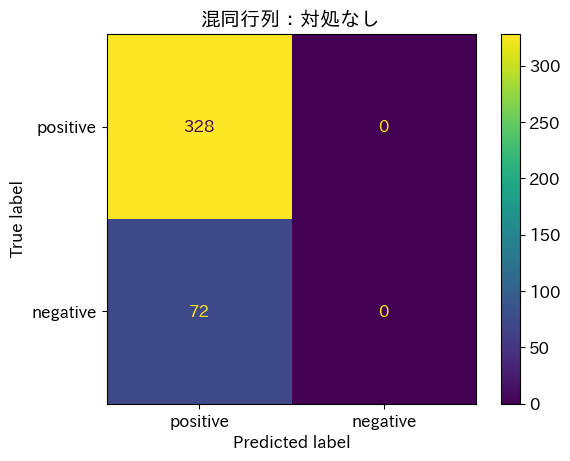

In [13]:
y_naive, probs_naive = train_eval(class_weights=None, tag="naive")
m_naive = report_metrics(y_true, y_naive, "学習：対処なし")

ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_naive, labels=[0, 1]), display_labels=LABELS
).plot()
plt.title("混同行列：対処なし")
plt.show()

## 7. クラス重み付き損失で対処

逆頻度でクラス重みを計算し、少数クラス（negative）の誤りを重く罰します。

/Users/yasuthompson/Documents/llm-book/dai-7-kai/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


クラス重み: positive=0.64 / negative=2.27


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/50 [00:00<?, ?it/s]

/Users/yasuthompson/Documents/llm-book/dai-7-kai/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

 84%|████████▍ | 21/25 [00:02<00:00,  9.78it/s]

 92%|█████████▏| 23/25 [00:02<00:00, 10.13it/s]

100%|██████████| 25/25 [00:02<00:00, 10.51it/s]

100%|██████████| 25/25 [00:02<00:00, 10.60it/s]

▼ 学習：クラス重み付き
  accuracy        : 0.833  ← 一見良く見える指標
  macro-F1        : 0.774
  balanced acc    : 0.860
  negative recall : 0.903  ← 少数クラスを拾えているか
              precision    recall  f1-score   support

    positive      0.975     0.817     0.889       328
    negative      0.520     0.903     0.660        72

    accuracy                          0.833       400
   macro avg      0.747     0.860     0.774       400
weighted avg      0.893     0.833     0.848       400



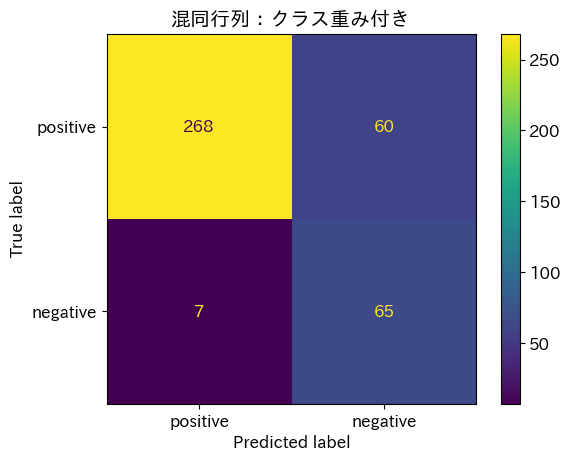

In [14]:
total = train_counts.sum()
weights = torch.tensor(
    [total / (2 * train_counts[0]), total / (2 * train_counts[1])],
    dtype=torch.float,
)
print(f"クラス重み: positive={weights[0]:.2f} / negative={weights[1]:.2f}")

y_weighted, probs_weighted = train_eval(class_weights=weights, tag="weighted")
m_weighted = report_metrics(y_true, y_weighted, "学習：クラス重み付き")

ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_weighted, labels=[0, 1]), display_labels=LABELS
).plot()
plt.title("混同行列：クラス重み付き")
plt.show()

## 8. 手法ごとの比較

accuracy はどれも高く見えますが、**negative recall / balanced acc** で差が出ます。

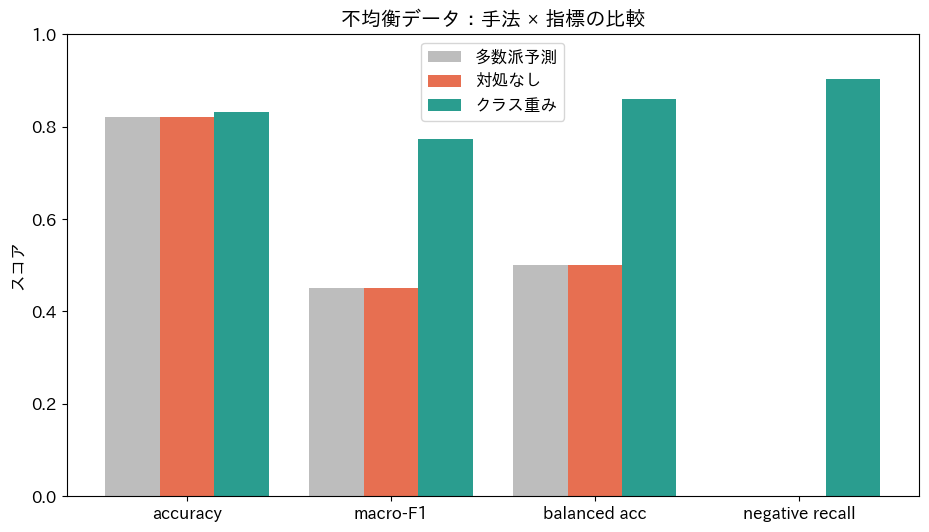

In [15]:
results = {"多数派予測": m_major, "対処なし": m_naive, "クラス重み": m_weighted}
metric_keys = ["accuracy", "macro_f1", "balanced_acc", "minority_recall"]
metric_labels = ["accuracy", "macro-F1", "balanced acc", "negative recall"]

x = np.arange(len(metric_keys))
methods = list(results.keys())
width = 0.8 / len(methods)
colors = ["#bdbdbd", "#e76f51", "#2a9d8f"]

plt.figure(figsize=(11, 6))
for i, mth in enumerate(methods):
    vals = [results[mth][k] for k in metric_keys]
    plt.bar(x + (i - (len(methods) - 1) / 2) * width, vals, width,
            label=mth, color=colors[i])
plt.xticks(x, metric_labels)
plt.ylim(0, 1)
plt.ylabel("スコア")
plt.title("不均衡データ：手法 × 指標の比較")
plt.legend()
plt.show()

比較結果をファイルに保存しておきます
（**補足ノート `03_amazon_logreg.ipynb`** で、ロジスティック回帰の結果と比べるため）。

In [16]:
import json
import os

os.makedirs("output", exist_ok=True)
# 集計結果（手法ごとの指標）
with open("output/nb2_bert_results.json", "w", encoding="utf-8") as f:
    json.dump(
        {name: {k: float(m[k]) for k in metric_keys}
         for name, m in results.items()},
        f, ensure_ascii=False, indent=2,
    )
print("保存しました: output/nb2_bert_results.json")

# 事例ごとの予測・確率（ノート3でエラー分析・RRF融合に使う）
# ※ ノート3も同じ load_amazon_binary + 同じ分割なので、検証セットの並びは一致する
np.savez(
    "output/nb2_bert_preds.npz",
    y_true=np.array(y_true),
    pred_naive=np.array(y_naive), prob_naive=probs_naive,
    pred_weighted=np.array(y_weighted), prob_weighted=probs_weighted,
)
print("保存しました: output/nb2_bert_preds.npz")

保存しました: output/nb2_bert_results.json
保存しました: output/nb2_bert_preds.npz


## 9. エラー分析 — 「自信満々で外した」事例

クラス重みモデルが、高い確信度で間違えた事例を見てみます。

In [17]:
errors = []
for i, (yt, yp) in enumerate(zip(y_true, y_weighted)):
    if yt != yp:
        errors.append((i, float(probs_weighted[i].max()), LABELS[yp], LABELS[yt]))
errors.sort(key=lambda e: -e[1])

for i, prob, pred_label, true_label in errors[:5]:
    print(f"予測確率={prob:.3f}  予測={pred_label} / 正解={true_label}")
    print(" ", valid_ds[i]["text"][:200])
    print("-" * 60)

予測確率=0.613  予測=negative / 正解=positive
  The pouch is stinky, but I ended up tossing it anyway. Bigger brushes aren't all that great, they shed. Can't beat tho. Still an excellent value
------------------------------------------------------------
予測確率=0.608  予測=negative / 正解=positive
  Too expensive for what used to cost $1.00.
------------------------------------------------------------
予測確率=0.606  予測=negative / 正解=positive
  No burrs, hold well.
------------------------------------------------------------
予測確率=0.593  予測=negative / 正解=positive
  Not as sticky as some are. Good for the price tho.
------------------------------------------------------------
予測確率=0.590  予測=negative / 正解=positive
  Not good<br />Don’t look<br />Like this
------------------------------------------------------------


## まとめ

- 学習の「型」は **tokenizer → 前処理/DataCollator → モデル → `Trainer`** で共通
- **不均衡データでは accuracy に騙されない**。少数クラスの recall / macro-F1 /
  balanced accuracy / 混同行列で評価する
- **クラス重み付き損失**で少数クラスを拾えるようになる（accuracy はほぼ変わらず、
  balanced acc・negative recall が改善）
- **エラー分析**で「自信満々の誤り」を観察すると、データやモデルの癖が見える